In this notebook I am going to try to replicate Figures 11 and 12 from Sadavoy, 2019 (https://ui.adsabs.harvard.edu/abs/2019ApJS..245....2S/abstract)

I am then going to try to adapt it to work for ALMA Band 5 and Band 7

## Load things

In [1]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FUNCTIONS/load_functions"

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


fortran mie routines unavailable


/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:47: UserWarning: could not import compiled mie code - mie calculation will be slow
  warnings.warn(


In [2]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/constants.py"

In [3]:
color = ['red', 'blue', 'green']
ls = ['-', '--', '-.']

## Primary Beam and Centre Point

In [4]:
pb_path = band6_data_folder_path + "c2d_989_pbeam_233GHz.fits"

header, _, pb_map, wcs = read_in_file(pb_path)

ny, nx = pb_map.shape

In [5]:
centre_string = centre_str_band6

centre_ra_deg, centre_dec_deg = find_ra_and_dec(centre_string)

x_cen, y_cen = find_pix(centre_ra_deg, centre_dec_deg, pb_path)

x_cen_int = int(x_cen)        # phase center x pixel
y_cen_int = int(y_cen)        # phase center y pixel



print(rf'The centre position is: (y, x) = ({y_cen}, {x_cen}), and at this position pb = {pb_map[y_cen_int, x_cen_int]}')

The centre position is: (y, x) = (827.3016564278106, 858.1226451256217), and at this position pb = 0.9999034404754639


Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [6]:
# fig, ax = simple_plot(wcs, pb_map, 'Primary Beam', 
#                            soft_colormap_v2, 
#                            0, nx, 0, ny)


# ax.scatter(x_cen, y_cen, marker = '*', s = 500, color = 'blue', label = 'Centre')

# ax.legend(fontsize = legend_text_fs)

## Radius Map and Test Values

In [7]:
pixel_scale = np.abs(header["CDELT1"]) * 3600  # arcsec/pixel

y_grid, x_grid = np.indices((ny, nx))

radius_map = np.sqrt((x_grid - x_cen)**2 + (y_grid - y_cen)**2) * pixel_scale

In [8]:
# fig, ax = simple_plot(wcs, radius_map, 'Radius', 
#                            soft_colormap_v2, 
#                            0, nx, 0, ny)


# ax.scatter(x_cen, y_cen, marker = '*', s = 500, color = 'blue', label = 'Centre')

# ax.legend(fontsize = legend_text_fs)

The paper says: We calculate the probability of detecting a galaxy at each threshold in annuli separated by $\sim 0.3''$

In [9]:
dr_arcsec = 0.3 
dr_deg = dr_arcsec / 206265

dr_pix = arcsec_to_pixels(header, 0.3)
dr_pix

16.666666666666664

In [10]:
end_x = nx - 1
end_y = y_cen_int

max_radius = radius_map[end_y, end_x]

dr_arcsec = 0.3 
dr_deg = dr_arcsec / 206265

radius_array_arcsec = np.arange(0, max_radius + dr_arcsec, dr_arcsec)

# make dataframe
df = pd.DataFrame({"r_arcsec": radius_array_arcsec})

df["r_deg"] = radius_array_arcsec / 206265

In [11]:
area_annulus_arr = []
area_annulus_arr_v2 = []

for i in range(len(df)):
    
    if i == len(df) - 1:
        area_annulus_arr.append(0)  # no outer annulus for the last bin
        area_annulus_arr_v2.append(0)
    else:
            
        rmin_deg = df["r_deg"][i]
        rmax_deg = df["r_deg"][i + 1]

        # Calculate annulus area in deg^2
        area_annulus = np.pi * (rmax_deg**2 - rmin_deg**2)
        area_annulus_v2 = 2 * np.pi * (rmax_deg + rmin_deg/2) * dr_deg

        area_annulus_arr.append(area_annulus)
        area_annulus_arr_v2.append(area_annulus_v2)
        
df["area_annulus"] = area_annulus_arr
df["area_annulus_v2"] = area_annulus_arr_v2

In [12]:
x_pos_arr = []
pb_val_arr = []
sigma_r_arr = []

radius_row = radius_map[y_cen_int, :]


for i in range(len(df) ):

    rmin = df["r_arcsec"][i]

    x_pos = np.argmin(np.abs(radius_row - rmin))

    # Extract the pb at this value 
    pb_val = pb_map[y_cen_int, x_pos]

    sigma_r = 0.03 / pb_val
    
    x_pos_arr.append(x_pos)
    pb_val_arr.append(pb_val)
    sigma_r_arr.append(sigma_r)
    
df["x_pos"] = x_pos_arr
df["pb_val"] = pb_val_arr
df["sigma_r"] = sigma_r_arr        

In [13]:
df

,r_arcsec,r_deg,area_annulus,area_annulus_v2,x_pos,pb_val,sigma_r
0,0.0,0.000000,6.645709e-12,1.329142e-11,858,0.999903,0.030003
1,0.3,0.000001,1.993713e-11,3.322854e-11,875,0.999886,0.030003
2,0.6,0.000003,3.322854e-11,5.316567e-11,825,0.999599,0.030012
3,0.9,0.000004,4.651996e-11,7.310280e-11,908,0.999415,0.030018
4,1.2,0.000006,5.981138e-11,9.303992e-11,925,0.998650,0.030041
5,1.5,0.000007,7.310280e-11,1.129770e-10,775,0.996177,0.030115
6,1.8,0.000009,8.639421e-11,1.329142e-10,958,0.995137,0.030147
7,2.1,0.000010,9.968563e-11,1.528513e-10,975,0.991872,0.030246
8,2.4,0.000012,1.129770e-10,1.727884e-10,725,0.984641,0.030468
9,2.7,0.000013,1.262685e-10,1.927256e-10,1008,0.982240,0.030542


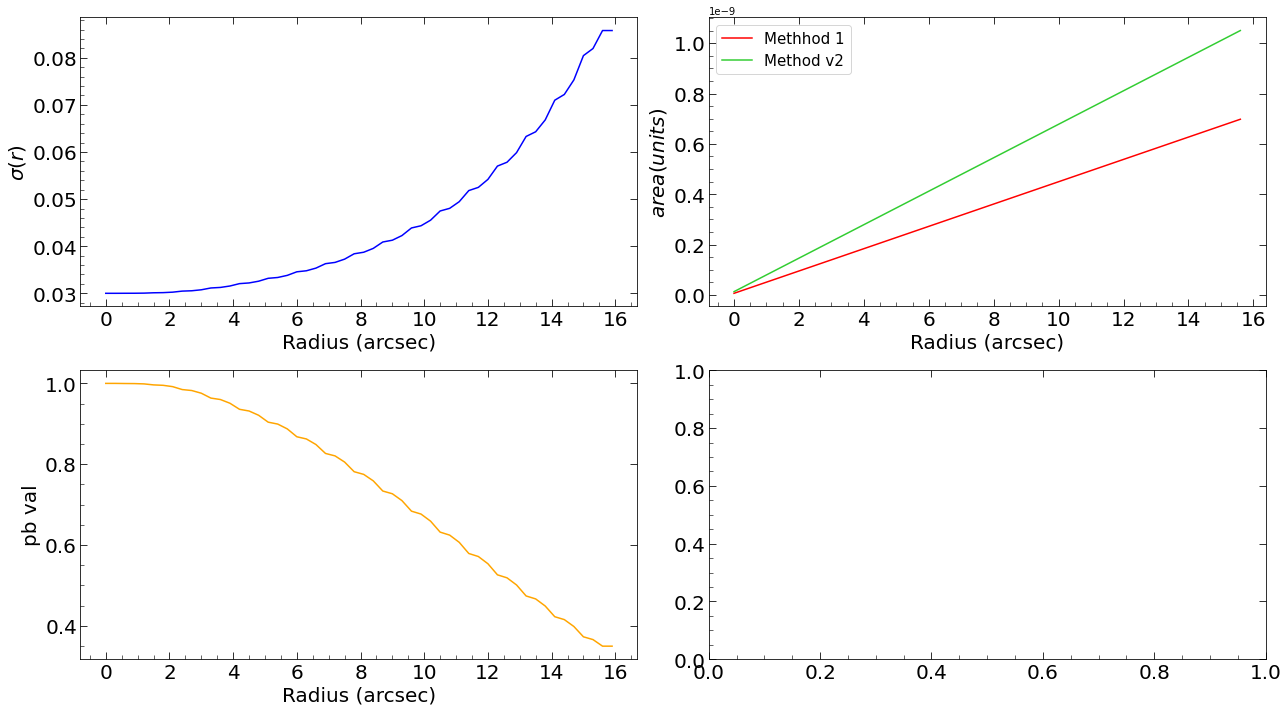

In [14]:
# ---------------------------
# Plot
# ---------------------------
fig, ax = plt.subplots(2, 2, figsize=(18,10))


# Top left 
ax[0, 0].plot(df["r_arcsec"], df["sigma_r"], color = 'blue')
ax[0, 0].set_xlabel('Radius (arcsec)', fontsize=axis_label_fs)
ax[0, 0].set_ylabel('$\sigma(r)$', fontsize=axis_label_fs)


# Top right 
ax[0, 1].plot(df["r_arcsec"].iloc[:-1], df["area_annulus"].iloc[:-1], color = 'red', label = 'Methhod 1')
ax[0, 1].plot(df["r_arcsec"].iloc[:-1], df["area_annulus_v2"].iloc[:-1], color = 'limegreen', label = 'Method v2')
ax[0, 1].set_xlabel('Radius (arcsec)', fontsize=axis_label_fs)
ax[0, 1].set_ylabel('$area (units)$', fontsize=axis_label_fs)
ax[0, 1].legend(fontsize = legend_text_fs)


# Bottom left 
ax[1, 0].plot(df["r_arcsec"], df["pb_val"], color = 'orange')
ax[1, 0].set_xlabel('Radius (arcsec)', fontsize=axis_label_fs)
ax[1, 0].set_ylabel('pb val', fontsize=axis_label_fs)

# Botom Right


for i in range(2):
    for j in range(2):
        ax[i, j].minorticks_on()
        ax[i, j].tick_params(axis="x", which="major", direction="in", bottom=True, top=True, length=7, labelsize=axis_num_fs)
        ax[i, j].tick_params(axis="y", which="major", direction="in", left=True, right=True, length=7, labelsize=axis_num_fs)
        ax[i, j].tick_params(which='minor', length=4, direction="in")


plt.tight_layout()
plt.show()

## $\sigma(r)$

The paper says: $\sigma(r)$ is the map sensitivity as a function of position in the pimary beam. We adopt $\sigma=0.03$ mJy at the phase centre and allow $\sigma(r)$ to increase at larger radial extents accoring to the primary beam correction. 


More info:
divide the central sensitivity value (e.g., 0.03 mJy) by the primary beam value from the *.pb file.  So your noise goes up as you move away from the middle
 

## Galaxy Probability

The paper says: a Schechter function of the differential galaxy numbers of:

where $N$ is the number of galaxies with intensity $S$, and $S_0$ = 1.7 mJy. 

In [18]:
StokesI_header

NameError: name 'StokesI_header' is not defined

In [15]:
# radius_left = radius_array_arcsec


sn_levels = [5, 10 , 20]

prob_band6_norm = []           
prob_band6_cumulative = []  

    
    
for sn in sn_levels: 
    
    prob_annuli = []
    
    
    for i in range(len(df) - 1):
        
        S = sn * df["sigma_r"][i]

        
        dN_dS_annulus = galaxy_probability(S, 'Band 6')
        dN_dS_mean = np.nanmean(dN_dS_annulus)
        
        # Calculate annulus area in deg^2
        area_annulus = df["area_annulus"][i]
        
        # Expected number of galaxies in annulus
        N = dN_dS_mean * area_annulus
        
        prob_annuli.append(N)  # append to list here
    
    prob_annuli = np.array(prob_annuli)
    
    # Normalize differential probabilities as percentage of total counts
    prob_annuli_norm = 100 * prob_annuli / np.nansum(prob_annuli)
    prob_band6_norm.append(prob_annuli_norm)
    
    # Compute cumulative probability (%)
    cumulative_prob= np.cumsum(prob_annuli_norm)
    prob_band6_cumulative.append(cumulative_prob)
    

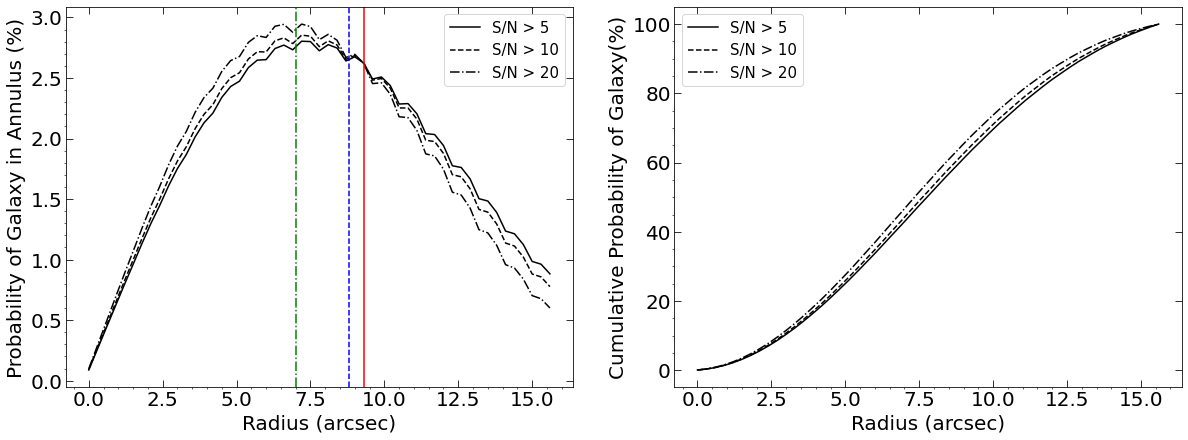

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(20, 7))


for i, N in enumerate(sn_levels):
    # Annular detection probability
    ax[0].plot(df["r_arcsec"][:-1], prob_band6_norm[i], color='black', ls=ls[i], label=f'S/N > {N}')
    
    # Cumulative probability
    ax[1].plot(df["r_arcsec"][:-1], prob_band6_cumulative[i], color='black', ls=ls[i], label=f'S/N > {N}')
    


ax[0].set_ylabel('Probability of Galaxy in Annulus (%)', fontsize = axis_label_fs)
ax[1].set_ylabel('Cumulative Probability of Galaxy(%)',  fontsize = axis_label_fs)


for i in range(2):
    
    # Add axis labels
    ax[i].set_xlabel(r'Radius (arcsec)', fontsize=axis_label_fs)


    # Adjust ticks
    ax[i].minorticks_on()
    ax[i].tick_params(axis="x", which="major", direction="in", bottom=True, top=True, length=7, labelsize=axis_num_fs)
    ax[i].tick_params(axis="y", which="major", direction="in", left=True, right=True, length=7, labelsize=axis_num_fs)
    
    ax[i].legend(fontsize = legend_text_fs)

# Mark the peak probability to see if it lines up with the paper
peaks = [9.3, 8.8, 7]
color = ['red', 'blue', 'green']

for i in range(3):
    ax[0].axvline(peaks[i], color = color[i], ls = ls[i])
    

If you print dN/dS (ignore the area term) for let's say r = 10.5 where the pb_corr is 0.78.  That means that the S0 value for the dN/dS equation should be 0.19 for 5sigma, 0.385 for 10sigma, and 0.77 for 20sigma

In [ ]:
# Find the row of 